## Import needed modules

In [1]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


## Create needed functions

### Functions to Create Data Frame from Dataset

#### Function to create data frame

In [2]:
# Generate data paths with labels
def define_paths(data_dir):
    filepaths = []
    labels = []

    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)

    return filepaths, labels


# Concatenate data paths with labels into one dataframe ( to later be fitted into the model )
def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)

# Split dataframe to train, valid, and test
def split_data(data_dir):
    # train dataframe
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    strat = df['labels']
    train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

    # valid and test dataframe
    strat = dummy_df['labels']
    valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 123, stratify= strat)

    return train_df, valid_df, test_df

#### Function to generate images from dataframe

In [3]:
def create_gens (train_df, valid_df, test_df, batch_size):
    '''
    This function takes train, validation, and test dataframe and fit them into image data generator, because model takes data from image data generator.
    Image data generator converts images into tensors. '''


    # define model parameters
    img_size = (224, 224)
    channels = 3 # either BGR or Grayscale
    color = 'rgb'
    img_shape = (img_size[0], img_size[1], channels)

    # Recommended : use custom function for test data batch size, else we can use normal batch size.
    ts_length = len(test_df)
    test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    test_steps = ts_length // test_batch_size

    # This function which will be used in image data generator for data augmentation, it just take the image and return it again.
    def scalar(img):
        return img

    tr_gen = ImageDataGenerator(preprocessing_function= scalar, horizontal_flip= True)
    ts_gen = ImageDataGenerator(preprocessing_function= scalar)

    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    # Note: we will use custom test_batch_size, and make shuffle= false
    test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= False, batch_size= test_batch_size)

    return train_gen, valid_gen, test_gen

#### Function to display data sample

In [4]:
def show_images(gen):
    '''
    This function take the data generator and show sample of the images
    '''

    # return classes , images to be displayed
    g_dict = gen.class_indices        # defines dictionary {'class': index}
    classes = list(g_dict.keys())     # defines list of dictionary's kays (classes), classes names : string
    images, labels = next(gen)        # get a batch size samples from the generator

    # calculate number of displayed samples
    length = len(labels)        # length of batch size
    sample = min(length, 25)    # check if sample less than 25 images

    plt.figure(figsize= (20, 20))

    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255       # scales data to range (0 - 255)
        plt.imshow(image)
        index = np.argmax(labels[i])  # get image index
        class_name = classes[index]   # get class of image
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

#### Callbacks

Callbacks : Helpful functions to help optimize model training
Examples: stop model training after specfic time, stop training if no improve in accuracy and so on.


In [5]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        #self.model = model
        self.patience = patience # specifies how many epochs without improvement before learning rate is adjusted
        self.stop_patience = stop_patience # specifies how many times to adjust lr without improvement to stop training
        self.threshold = threshold # specifies training accuracy threshold when lr will be adjusted based on validation loss
        self.factor = factor # factor by which to reduce the learning rate
        self.batches = batches # number of training batch to run per epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch # save this value to restore if restarting training

        # callback variables
        self.count = 0 # how many times lr has been reduced without improvement
        self.stop_count = 0
        self.best_epoch = 1   # epoch with the lowest loss
        #self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr)) # get the initial learning rate and save it
        self.highest_tracc = 0.0 # set highest training accuracy to 0 initially
        self.lowest_vloss = np.inf # set lowest validation loss to infinity initially
        # self.best_weights = self.model.get_weights() # set best weights to model's initial weights
        # self.initial_weights = self.model.get_weights()   # save initial weights if they have to get restored

    # Define a function that will run when train begins
    def on_train_begin(self, logs= None):
        self.best_weights = self.model.get_weights() # set best weights to model's initial weights
        self.initial_weights = self.model.get_weights()   # save initial weights if they have to get restored
        # get the initial learning rate and save it
        self.initial_lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        msg = 'Do you want model asks you to halt the training [y/n] ?'
        print(msg)
        ans = input('')
        if ans in ['Y', 'y']:
            self.ask_permission = 1
        elif ans in ['N', 'n']:
            self.ask_permission = 0

        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()


    def on_train_end(self, logs= None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print(msg)

        # set the weights of the model to the best weights
        self.model.set_weights(self.best_weights)


    def on_train_batch_end(self, batch, logs= None):
        # get batch accuracy and loss
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')

        # prints over on the same line to show running batch count
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
        print(msg, '\r', end= '')


    def on_epoch_begin(self, epoch, logs= None):
        self.ep_start = time.time()


    # Define method runs on the end of each epoch
    def on_epoch_end(self, epoch, logs= None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)) # get the current learning rate
        current_lr = lr
        acc = logs.get('accuracy')  # get training accuracy
        v_acc = logs.get('val_accuracy')  # get validation accuracy
        loss = logs.get('loss')  # get training loss for this epoch
        v_loss = logs.get('val_loss')  # get the validation loss for this epoch

        if acc < self.threshold: # if training accuracy is below threshold adjust lr based on training accuracy
            monitor = 'accuracy'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc ) * 100 / self.highest_tracc # define improvement of model progres

            if acc > self.highest_tracc: # training accuracy improved in the epoch
                self.highest_tracc = acc # set new highest training accuracy
                self.best_weights = self.model.get_weights() # training accuracy improved so save the weights
                self.count = 0 # set count to 0 since training accuracy improved
                self.stop_count = 0 # set stop counter to 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1  # set the value of best epoch for this epoch

            else:
                # training accuracy did not improve check if this has happened for patience number of epochs
                # if so adjust learning rate
                if self.count >= self.patience - 1: # lr should be adjusted
                    lr = lr * self.factor # adjust the learning by factor
                    self.model.optimizer.learning_rate.assign(lr) # set the learning rate in the optimizer
                    self.count = 0 # reset the count to 0
                    self.stop_count = self.stop_count + 1 # count the number of consecutive lr adjustments
                    self.count = 0 # reset counter
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1 # increment patience counter

        else: # training accuracy is above threshold so adjust learning rate based on validation loss
            monitor = 'val_loss'
            if epoch == 0:
                pimprov = 0.0

            else:
                pimprov = (self.lowest_vloss - v_loss ) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss: # check if the validation loss improved
                self.lowest_vloss = v_loss # replace lowest validation loss with new validation loss
                self.best_weights = self.model.get_weights() # validation loss improved so save the weights
                self.count = 0 # reset count since validation loss improved
                self.stop_count = 0
                self.best_epoch = epoch + 1 # set the value of the best epoch to this epoch

            else: # validation loss did not improve
                if self.count >= self.patience - 1: # need to adjust lr
                    lr = lr * self.factor # adjust the learning rate
                    self.stop_count = self.stop_count + 1 # increment stop counter because lr was adjusted
                    self.count = 0 # reset counter
                    self.model.optimizer.learning_rate.assign(lr) # set the learning rate in the optimizer

                else:
                    self.count = self.count + 1 # increment the patience counter

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1: # check if learning rate has been adjusted stop_count times with no improvement
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True # stop training

        else:
            if self.ask_epoch != None and self.ask_permission != 0:
                if epoch + 1 >= self.ask_epoch:
                    msg = 'enter H to halt training or an integer for number of epochs to run then ask again'
                    print(msg)

                    ans = input('')
                    if ans == 'H' or ans == 'h':
                        msg = f'training has been halted at epoch {epoch + 1} due to user input'
                        print(msg)
                        self.model.stop_training = True # stop training

                    else:
                        try:
                            ans = int(ans)
                            self.ask_epoch += ans
                            msg = f' training will continue until epoch {str(self.ask_epoch)}'
                            print(msg)
                            msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration')
                            print(msg)

                        except Exception:
                            print('Invalid')

#### Function to plot history of training

In [6]:
def plot_training(hist):
    '''
    This function take training model and plot history of accuracy and losses with the best epoch in both of them.
    '''

    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']

    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]

    Epochs = [i+1 for i in range(len(tr_acc))]

    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()

### Model Structure

#### Start Reading Dataset

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

In [ ]:
!unzip plantvillage-dataset.zip

In [ ]:
# save work

from google.colab import drive
drive.mount('/content/drive')

import shutil

src = '/content/plantvillage dataset'
dst = '/content/drive/MyDrive/plantvillage dataset'

shutil.copytree(src, dst, dirs_exist_ok=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
data_dir = '/content/drive/MyDrive/plantvillage dataset/color'

try:
    # Get splitted data
    train_df, valid_df, test_df = split_data(data_dir)

    # Get Generators
    batch_size = 40
    train_gen, valid_gen, test_gen = create_gens(train_df, valid_df, test_df, batch_size)

except:
    print('Invalid Input')

Found 3548 validated image filenames belonging to 4 classes.
Found 444 validated image filenames belonging to 4 classes.
Found 444 validated image filenames belonging to 4 classes.


#### Display Image Sample

In [8]:
show_images(train_gen)

Output hidden; open in https://colab.research.google.com to view.

#### Generic Model Creation

In [9]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can built on pretrained model such as :  efficientnet, VGG , Resnet )
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.efficientnet.EfficientNetB3(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2( 0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 11,093,804 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

#### Set Callback Parameters

In [10]:
batch_size = 40   # set batch size for training
epochs = 40   # number of all epochs in training
patience = 1   #number of epochs to wait to adjust lr if monitored value does not improve
stop_patience = 3   # number of epochs to wait before stopping training if monitored value does not improve
threshold = 0.9   # if train accuracy is < threshold adjust monitor accuracy, else monitor validation loss
factor = 0.5   # factor to reduce lr by
ask_epoch = 5   # number of epochs to run before asking if you want to halt training
batches = int(np.ceil(len(train_gen.labels) / batch_size))    # number of training batch to run per epoch

callbacks = [MyCallback(patience= patience, stop_patience= stop_patience, threshold= threshold,
            factor= factor, batches= batches, epochs= epochs, ask_epoch= ask_epoch )]

#### Train model

#### Test Model

In [11]:
print(model.optimizer)
print(dir(model.optimizer))

assert hasattr(model.optimizer, "learning_rate"), "Optimizer has no learning_rate"

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_trackable_child', '_add_variable_with_custom_getter', '_all_reduce_sum_gradients', '_api_export_path', '_api_export_symbol_id', '_apply_weight_decay', '_backend_apply_gradients', '_backend_increment_gradient_accumulators', '_backend_reset_gradient_accumulators', '_backend_update_step', '_check_super_called', '_check_variables_are_known', '_checkpoint_adapter', '_checkpoint_dependencies', '_clip_by_norm', '_clip_gradients', '_copy_trackable_to_cpu', '_deferred_dependencies', '_delete_tracking', '_deserialization_dependencies', '_deserialize_from_proto', '_distributed_tf_update_step', '_distribution_strategy', '_export_to_saved

In [12]:
history = model.fit(
    x=train_gen,
    epochs=3,
    steps_per_epoch=2,
    validation_data=valid_gen,
    validation_steps=1,        # only 1 val batch
    callbacks=callbacks,
    verbose=1,
    shuffle=False
)

Do you want model asks you to halt the training [y/n] ?
n
 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.2563 - loss: 40.1270  1 /40    39.669   31.250  75.15142  40.000   0.00100  0.00100  accuracy     0.00    187.93 
2/2 ━━━━━━━━━━━━━━━━━━━━ 188s 30s/step - accuracy: 0.3125 - loss: 39.6692 - val_accuracy: 0.4000 - val_loss: 75.1514
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7563 - loss: 37.6026    2 /40    37.199   78.750  77.77538  60.000   0.00100  0.00100  accuracy    152.00   12.69  
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.7875 - loss: 37.1993 - val_accuracy: 0.6000 - val_loss: 77.7754
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7625 - loss: 35.5281 3 /40    35.120   80.000  79.25191  62.500   0.00100  0.00100  accuracy     1.59    12.03  
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 11s/step - accuracy: 0.8000 - loss: 35.1197 - val_accuracy: 0.

In [13]:
history = model.fit(x= train_gen, epochs= epochs, verbose= 1, callbacks= callbacks,
                    validation_data= valid_gen, validation_steps= None, shuffle= False)

Do you want model asks you to halt the training [y/n] ?
n
 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
Epoch 1/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6908 - loss: 15.7411 1 /40    10.541   56.285   8.01519  42.117   0.00100  0.00050  accuracy     0.00    699.04 
89/89 ━━━━━━━━━━━━━━━━━━━━ 699s 8s/step - accuracy: 0.5629 - loss: 10.5406 - val_accuracy: 0.4212 - val_loss: 8.0152
Epoch 2/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.4035 - loss: 7.4678 2 /40     7.404   40.135   7.28731  40.315   0.00050  0.00025  accuracy    -49.83   29.75  
89/89 ━━━━━━━━━━━━━━━━━━━━ 30s 331ms/step - accuracy: 0.4014 - loss: 7.4041 - val_accuracy: 0.4032 - val_loss: 7.2873
Epoch 3/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.4131 - loss: 7.2639 3 /40     7.224   40.333   7.15236  40.315   0.00025  0.00013  accuracy    -49.58   29.96  
 training has been halted at epoch 3 after 3 adjustments of learning rate with no i

#### Display model performance

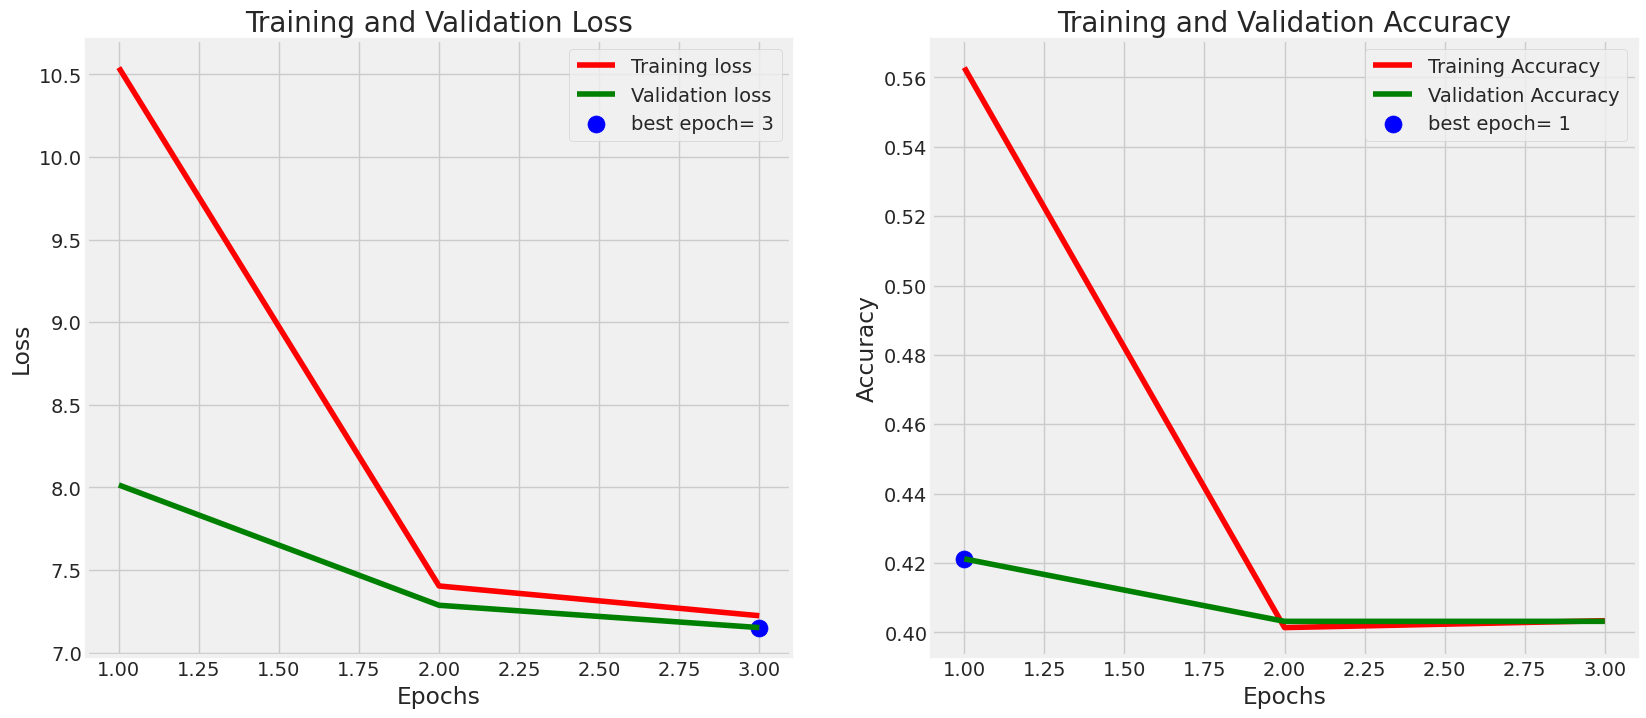

In [14]:
plot_training(history)

### Evaluate model

In [15]:
ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.5750 - loss: 78.8190
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5917 - loss: 78.4454
6/6 ━━━━━━━━━━━━━━━━━━━━ 78s 11s/step - accuracy: 0.5698 - loss: 138.4496
Train Loss:  78.81902313232422
Train Accuracy:  0.574999988079071
--------------------
Validation Loss:  78.44542694091797
Validation Accuracy:  0.5916666388511658
--------------------
Test Loss:  138.44961547851562
Test Accuracy:  0.5698198080062866


### Get Predictions

In [17]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
print(y_pred)

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step
[3 0 2 2 3 2 2 3 0 3 3 2 3 2 0 2 0 2 2 2 2 3 2 2 2 1 1 0 0 1 2 2 2 2 2 2 0
 2 3 2 2 0 3 2 3 2 1 2 2 0 1 1 2 2 2 3 2 3 2 1 2 3 0 0 2 2 2 0 0 0 0 2 0 0
 3 0 2 2 0 2 2 2 3 3 0 2 0 2 3 1 0 2 2 3 2 2 0 2 0 2 2 2 3 1 3 3 3 2 3 3 2
 2 2 3 2 1 3 2 2 2 1 0 2 2 2 1 2 1 3 2 2 2 2 2 3 1 2 1 0 1 2 0 0 2 0 0 1 0
 0 2 2 2 2 3 2 2 2 0 1 3 0 1 2 0 2 2 2 2 2 0 1 2 2 3 3 2 2 0 2 1 2 1 2 3 3
 0 3 2 2 2 0 0 2 3 0 2 3 2 2 0 1 0 2 0 3 2 2 2 2 0 2 2 2 1 1 0 1 3 2 2 2 0
 2 1 3 2 2 2 2 2 0 2 3 2 2 1 1 2 2 2 0 2 2 2 1 0 0 0 1 3 2 3 0 2 3 1 1 2 2
 0 1 2 3 3 3 2 1 2 2 0 3 2 0 2 3 0 2 3 1 2 3 1 0 0 3 2 2 2 3 1 0 3 2 3 2 0
 0 0 1 2 3 0 2 0 1 2 2 3 1 3 2 3 2 2 2 2 2 2 2 2 2 2 1 2 2 2 3 2 3 2 2 2 3
 2 2 2 2 3 2 0 0 3 2 2 2 0 0 2 3 2 2 1 2 2 0 2 3 2 3 1 0 2 2 1 2 2 3 1 2 3
 2 3 2 2 1 2 2 0 0 2 2 2 2 1 2 2 0 2 2 2 0 1 3 1 3 2 2 2 2 3 0 2 2 2 2 2 0
 2 2 2 0 3 2 2 0 3 3 3 1 0 3 1 0 3 2 3 0 2 3 2 3 2 2 3 3 2 1 2 3 2 2 1 3 3]


#### Confusion Matrics and Classification Report

In [18]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))


                                          precision    recall  f1-score   support

                Apple___Cedar_apple_rust       0.06      0.18      0.09        28
             Corn_(maize)___Common_rust_       0.83      0.38      0.52       119
                       Grape___Black_rot       0.52      0.98      0.68       118
Orange___Haunglongbing_(Citrus_greening)       1.00      0.49      0.65       179

                                accuracy                           0.57       444
                               macro avg       0.60      0.51      0.49       444
                            weighted avg       0.77      0.57      0.59       444



#### Save model

In [21]:
model_name = "plant_disease_model"
subject = "PlantVillage"
acc = test_score[1] * 100

save_path = "/content/drive/MyDrive/plantvillage dataset"

# Save full model
save_id = f"{model_name}-{subject}-{acc:.2f}.h5"
model_save_loc = os.path.join(save_path, save_id)

model.save(model_save_loc)
print(f"Model saved at: {model_save_loc}")

# Save weights (optional)
weights_save_loc = os.path.join(save_path, f"{model_name}.weights.h5")
model.save_weights(weights_save_loc)
print(f"Weights saved at: {weights_save_loc}")

Model saved at: /content/drive/MyDrive/plantvillage dataset/plant_disease_model-PlantVillage-56.98.h5
Weights saved at: /content/drive/MyDrive/plantvillage dataset/plant_disease_model.weights.h5


#### Generate CSV files containing classes indicies & image size

In [22]:
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])

Index_series = pd.Series(list(class_dict.values()), name= 'class_index')
Class_series = pd.Series(list(class_dict.keys()), name= 'class')
Height_series = pd.Series(height, name= 'height')
Width_series = pd.Series(width, name= 'width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis= 1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index= False)
print(f'class csv file was saved as {csv_save_loc}')

class csv file was saved as /content/drive/MyDrive/plantvillage dataset/PlantVillage-class_dict.csv
